# Preguntas del taller 4

1. Crear una función que permita determinar las intensidades de los Píxeles vecinos a un determinado Píxel de coordenadas definidas por el usuario. Los argumentos de entrada son la imagen y las coordenadas, y la salida una matriz con las intensidades de
los 8‐vecinos del Píxel.

2. Probar el algoritmo con una imagen.

3. Probar el algoritmo con una imagen en escala de grises y con las coordenadas (82,29), (68,27), (112,89), (114,89) y (27,130) de la imagen binaria «piano.bmp».

4. Ejecutar la ecualización local del histograma de una imagen. Debe mostrar la imagen original, la imagen ecualizada y los histogramas de las imágenes.

5. Crear un programa basado en ciclos que permita adelantar la ecualización local del histograma de una imagen. Utilice la imagen “Piano.pgm” con el fin de observar los efectos causados por la ecualización (se recomienda ajustar Amin = 0.5 y Amax = 2.5).

6. Crear una función basada en ciclos, que permita realizar las principales operaciones lógicas entre dos imágenes.
Verificar el algoritmo con las imágenes «CuadroBinGrande.pgm» y «CuadroBinChico.pgm».

In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("resultados", exist_ok=True)

1. Crear una función que permita determinar las intensidades de los Píxeles vecinos a un determinado Píxel de coordenadas definidas por el usuario. Los argumentos de entrada son la imagen y las coordenadas, y la salida una matriz con las intensidades de
los 8‐vecinos del Píxel.

In [10]:
"""
x representa la coordenada horizontal o columna.
y representa la coordenada vertical o fila.

En NumPy y OpenCV, una imagen se accede usando:
imagen[y, x]

Es decir, primero se indica la fila y después la columna.
"""

def obtener_8_vecinos(imagen, x, y):
    filas, columnas = imagen.shape[:2]

    # Comprobar bordes para evitar acceder a píxeles fuera de la imagen
    if x <= 0 or x >= columnas - 1:
        raise ValueError("La coordenada x está fuera de los límites de la imagen.")
    if y <= 0 or y >= filas - 1:
        raise ValueError("La coordenada y está fuera de los límites de la imagen.")

    # Obtener los 8 vecinos
    vecinos = np.array([
        [
            imagen[y - 1, x - 1],  # Arriba izquierda
            imagen[y - 1, x],      # Arriba
            imagen[y - 1, x + 1]   # arriba derecha
        ],  
        [
            imagen[y, x - 1],      # Izquierda
            -1,         # Centro
            imagen[y, x + 1]      # Derecha
        ],
        [
            imagen[y + 1, x - 1],  # Abajo izquierda
            imagen[y + 1, x],      # Abajo
            imagen[y + 1, x + 1]   # Abajo derecha
        ]
    ],dtype=int)
    return vecinos

def obtener_8_vecinos_ciclos(imagen, x, y):
    filas, columnas = imagen.shape[:2]

    # Comprobar bordes para evitar acceder a píxeles fuera de la imagen
    if x <= 0 or x >= columnas - 1:
        raise ValueError("La coordenada x está fuera de los límites de la imagen.")
    if y <= 0 or y >= filas - 1:
        raise ValueError("La coordenada y está fuera de los límites de la imagen.")

    vecinos = np.full((3, 3), -1, dtype=int)  # Inicializar con -1 todos los valores

    #Recorrer las posiciones relativas de los vecinos
    for dy in range(-1, 2): # -1, 0, 1
        for dx in range(-1, 2): # -1, 0, 1
            if dy == 0 and dx == 0: # Centro, se deja como -1
                continue
            vecinos[dy + 1, dx + 1] = imagen[y + dy, x + dx]

    return vecinos

2. Probar el algoritmo con una imagen.

Píxel central: 128
8 vecinos:
[[157 124 127]
 [167  -1 134]
 [169 126 135]]


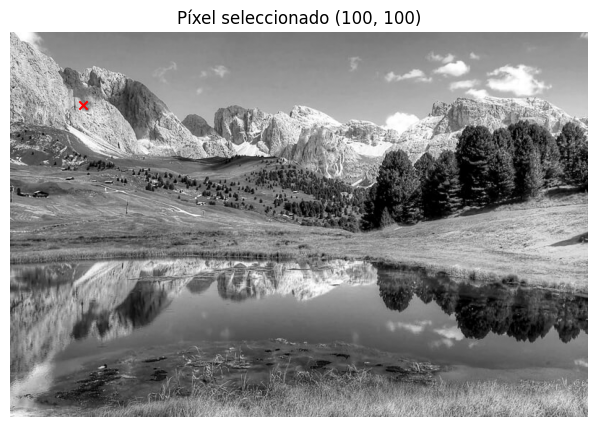

In [21]:
imagen = cv2.imread("images/paisaje.png", cv2.IMREAD_GRAYSCALE)

if imagen is None:
    raise FileNotFoundError("No se encontró la imagen en images/paisaje.png")

x, y = 100, 100

vecinos = obtener_8_vecinos(imagen, x, y)

print("Píxel central:", imagen[y, x])
print("8 vecinos:")
print(vecinos)
#Visualizacion punto
plt.figure(figsize=(8, 5))
plt.imshow(imagen, cmap="gray")

plt.scatter(
    x,
    y,
    marker="x",
    color="red"
)

plt.title(
    f"Píxel seleccionado ({x}, {y})"
)

plt.axis("off")
plt.savefig("resultados/punto1.png", bbox_inches="tight")
plt.show()


3. Probar el algoritmo con una imagen en escala de grises y con las coordenadas (82,29), (68,27), (112,89), (114,89) y (27,130) de la imagen binaria «piano.bmp».

In [ ]:
#3. Probar el algoritmo con una imagen en escala de grises y con las coordenadas (82,29), (68,27), (112,89), (114,89) y (27,130) de la imagen binaria «piano.bmp».
#coordenadas
coordenadas = [
    (82,29),
    (68,27),
    (112,89),
    (114,89),
    (27,130)
]

imagen_piano = cv2.imread("images/piano.bmp", cv2.IMREAD_GRAYSCALE)

for x, y in coordenadas:
    vecinos = obtener_8_vecinos(imagen_piano, x, y)
    print(f"Píxel central(coordenadas) ({x}, {y}):", imagen_piano[y, x])
    print("8 vecinos:")
    print(vecinos)
    print()  # Línea en blanco para separar resultados

Píxel central (82, 29): 63
8 vecinos:
[[ 53  65 103]
 [ 50  -1 105]
 [ 50  68 116]]

Píxel central (68, 27): 63
8 vecinos:
[[62 62 61]
 [62 -1 59]
 [61 64 58]]

Píxel central (112, 89): 59
8 vecinos:
[[66 61 64]
 [66 -1 63]
 [62 58 63]]

Píxel central (114, 89): 86
8 vecinos:
[[ 64  91 103]
 [ 63  -1 106]
 [ 63  73  93]]

Píxel central (27, 130): 93
8 vecinos:
[[ 90 102  90]
 [ 97  -1  82]
 [102  87  81]]

